In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_parquet('../cleaned_data/df_visual_data.parquet')

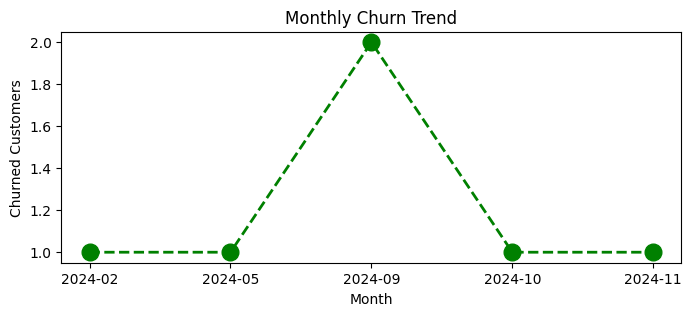

In [4]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df['cancellation_month'] = df['cancellation_date'].dt.to_period('M')

churn_trend = df[df['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values,  color='green', marker='o', linestyle='dashed',  linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

<Figure size 600x400 with 0 Axes>

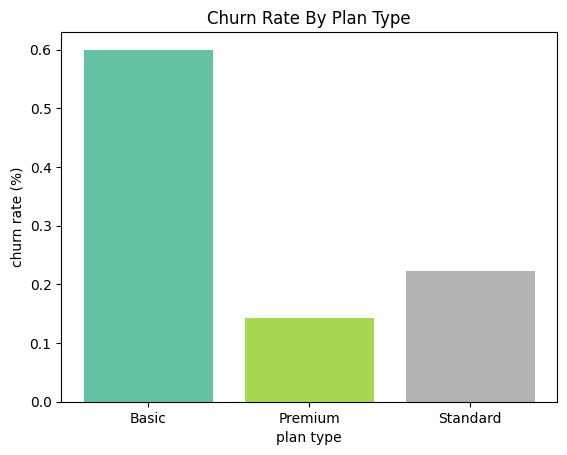

In [ ]:
# churn by plane type

churn_plan = df.groupby('plan_type')['churn_flag'].mean()

# colors = ['green','orange','blue']

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.bar(churn_plan.index , churn_plan.values , color = colors)
plt.title('Churn Rate By Plan Type')
plt.xlabel('plan type')
plt.ylabel('churn rate (%)')
plt.Figure(figsize= (6,4))

Text(0, 0.5, 'State')

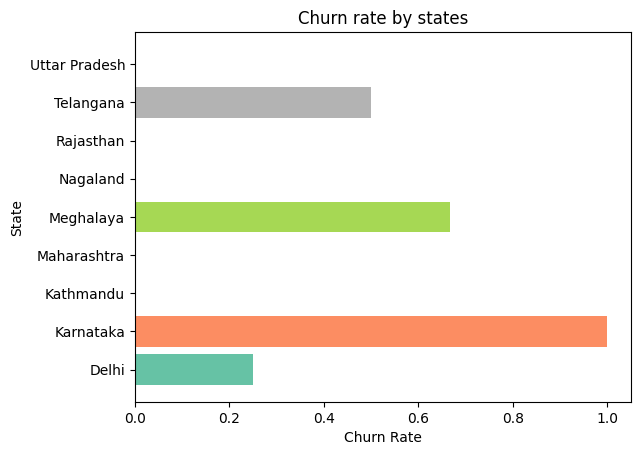

In [ ]:
#churn by states
churn_plan = df.groupby('state')['churn_flag'].mean()

colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.Figure(figsize=(10,6))

plt.barh(churn_plan.index,churn_plan.values,color = colors)
plt.title('Churn rate by states')
plt.xlabel('Churn Rate')
plt.ylabel('State')

In [ ]:
# For correct encoding order according to priorty in order_mapping

print('plan_type :', df['plan_type'].unique())
print('contract_type :', df['contract_type'].unique())
print('churn_risk :', df['churn_risk'].unique())

plan_type : <ArrowStringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <ArrowStringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <ArrowStringArray>
['low', 'high', 'med']
Length: 3, dtype: str


<Axes: >

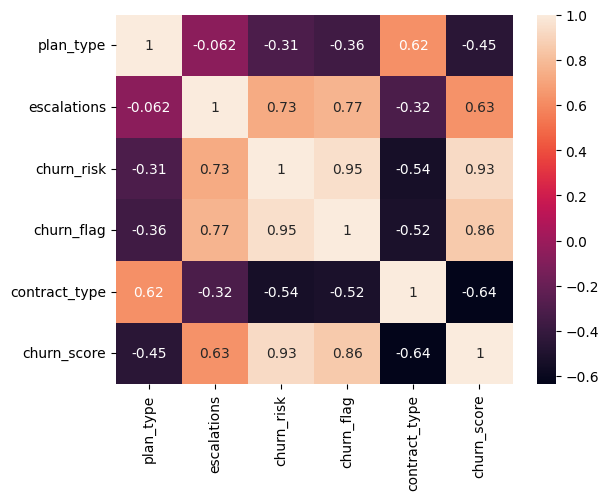

In [33]:
# Heatmap (Correlation Matrix)

# 1. encoding - based on priority
df_encoded = df[['plan_type','escalations','churn_risk','churn_flag','contract_type','churn_score']]

order_mapping = {
    'plan_type' : ['Basic','Standard','Premium'],
    'contract_type' : ['Monthly','Annual'],
    'churn_risk' : ['low','med','high']
}

for col , order in order_mapping.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'),categories=order , ordered=True).codes

# 2. Heatmap - using seaborn
sns.heatmap(df_encoded.corr(), annot=True)



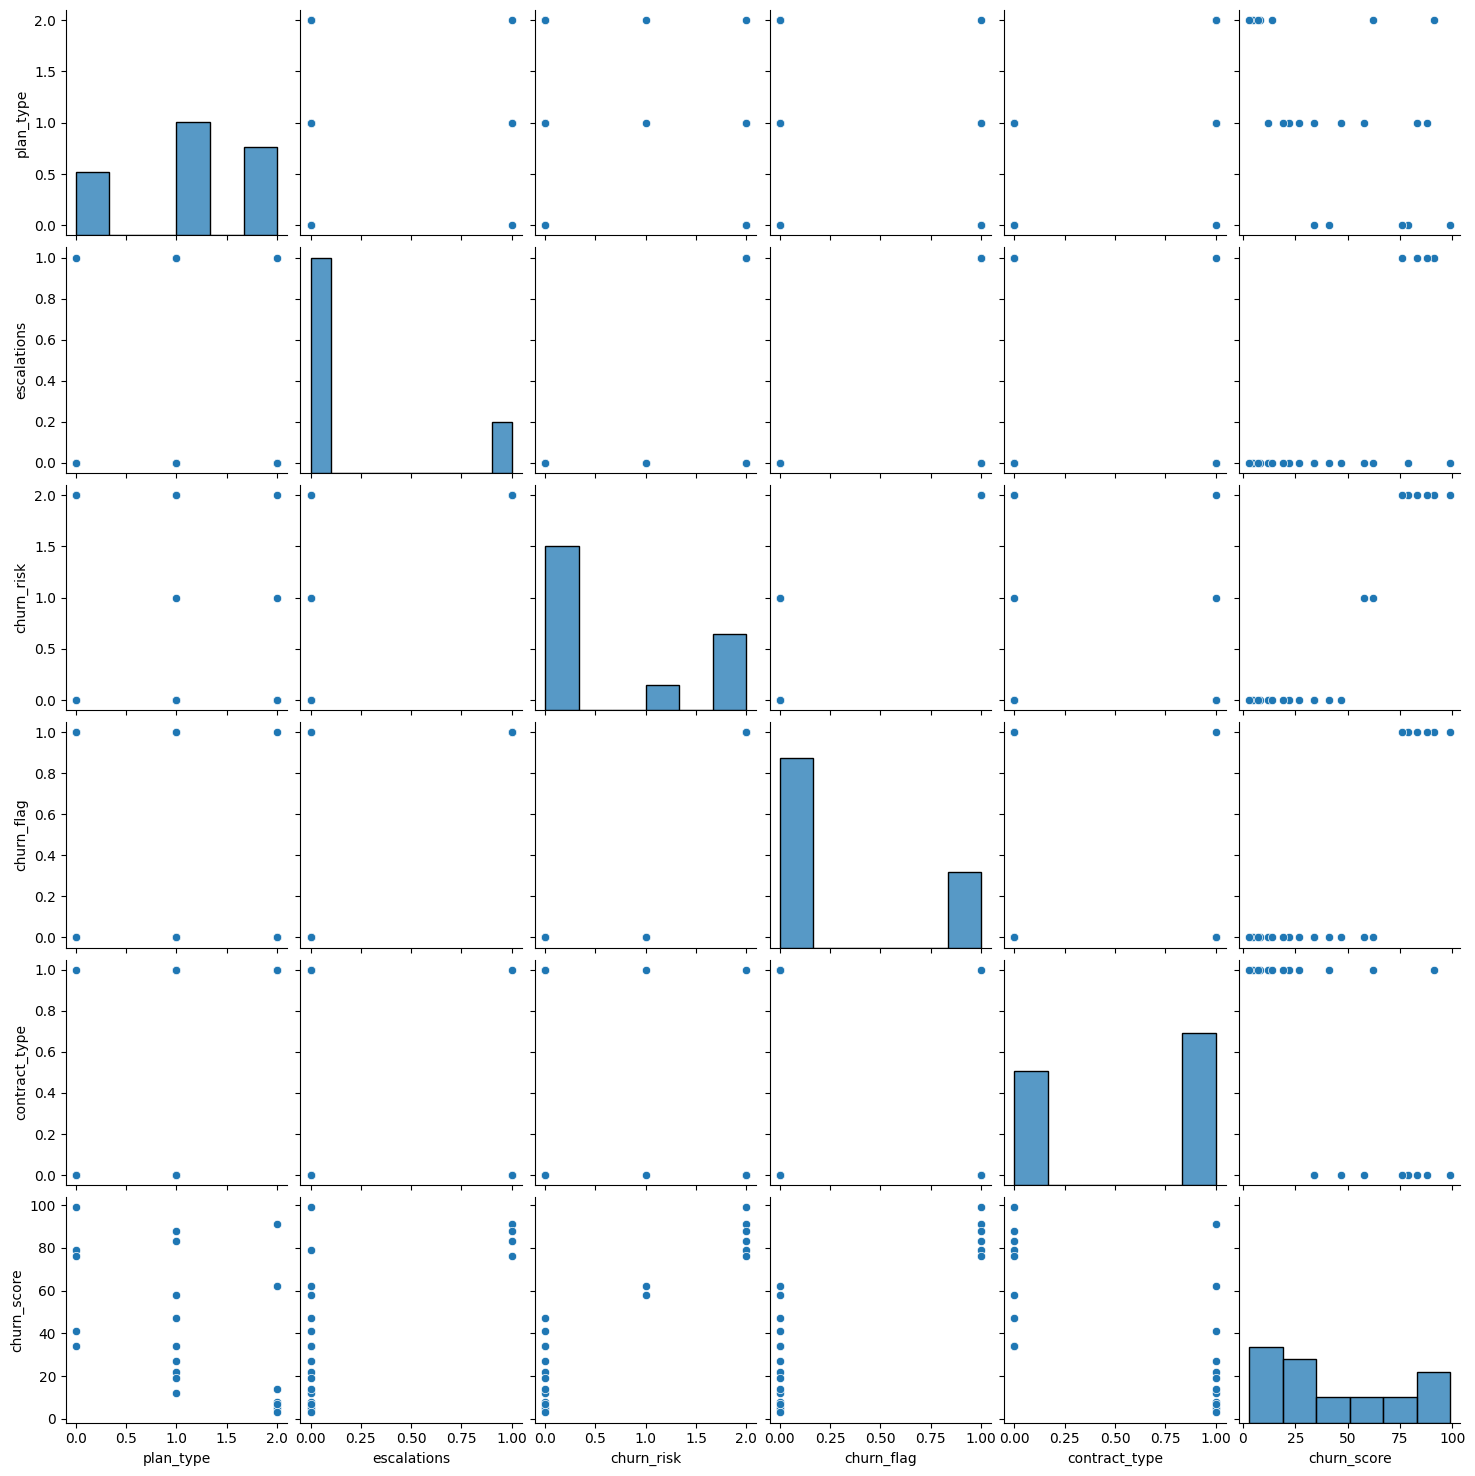

In [35]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)

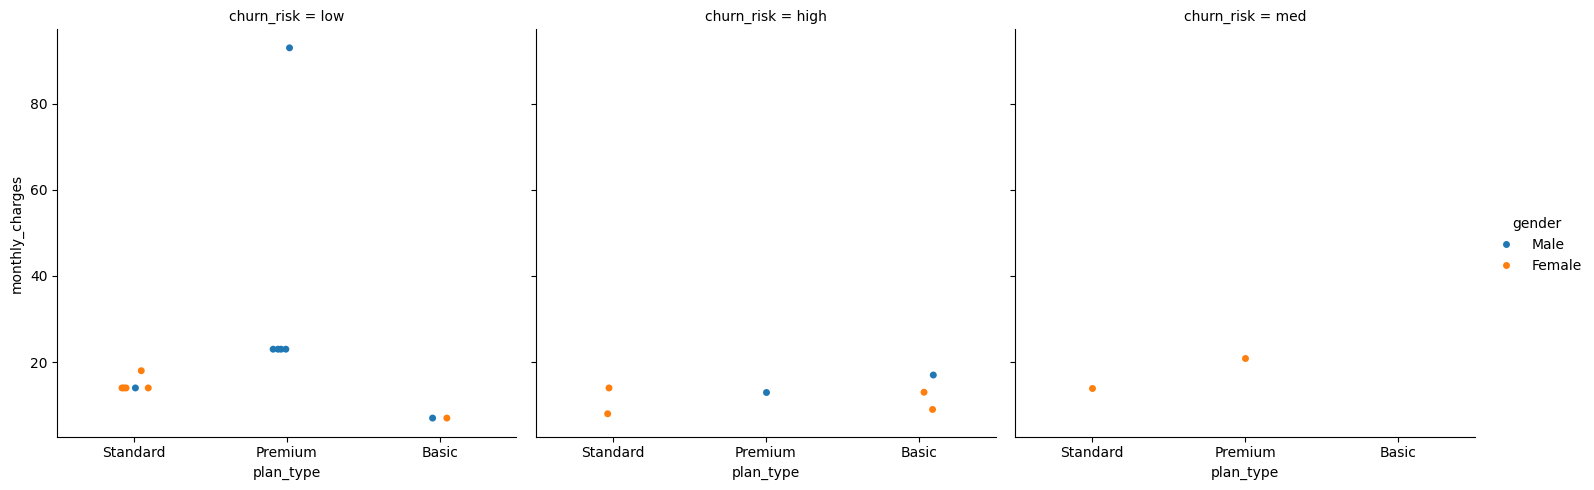

In [39]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(
    data=df,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk'
)